In [ ]:
# ==============================================================================
# TASK 2: HANDS-ON DATA LAB IMPLEMENTATION
# Candidate: Pradeep Singh
# Objectives: Environment Verification, Data Manipulation, Analysis & Plotting
# ==============================================================================

In [3]:
# ------------------------------------------------------------------------------
# 1. ENVIRONMENT & LIBRARY AUDIT
# ------------------------------------------------------------------------------
import sys
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns

print("=== Python & Environment Verification ===")
print(f"Python Version    : {sys.version.split()[0]}")
print(f"NumPy Version     : {np.__version__}")
print(f"Pandas Version    : {pd.__version__}")
print(f"Matplotlib Version: {matplotlib.__version__}")
print(f"Seaborn Version   : {sns.__version__}")
print("Environment Status: Functional and verified.\n")

=== Python & Environment Verification ===
Python Version    : 3.13.9
NumPy Version     : 2.3.5
Pandas Version    : 2.3.3
Matplotlib Version: 3.10.6
Seaborn Version   : 0.13.2
Environment Status: Functional and verified.



In [2]:
# ------------------------------------------------------------------------------
# 2. PRACTICAL LAB DATASET CREATION
# ------------------------------------------------------------------------------
# Creating a multi-feature sales/performance dataset
lab_data = {
    "Record_ID": [1001, 1002, 1003, 1004, 1005, 1006, 1007, 1008],
    "Region": ["North", "South", "East", "West", "North", "South", "East", "West"],
    "Product_Category": ["Hardware", "Software", "Hardware", "Services", "Services", "Software", "Hardware", "Services"],
    "Units_Sold": [15, 28, 12, 45, 30, 22, 18, 50],
    "Unit_Price": [250.0, 120.0, 310.0, 85.0, 95.0, 140.0, 290.0, 75.0]
}

df_lab = pd.DataFrame(lab_data)
df_lab["Total_Revenue"] = df_lab["Units_Sold"] * df_lab["Unit_Price"]

print("=== Initial Lab Dataset ===")
print(df_lab)

=== Initial Lab Dataset ===
   Record_ID Region Product_Category  Units_Sold  Unit_Price  Total_Revenue
0       1001  North         Hardware          15       250.0         3750.0
1       1002  South         Software          28       120.0         3360.0
2       1003   East         Hardware          12       310.0         3720.0
3       1004   West         Services          45        85.0         3825.0
4       1005  North         Services          30        95.0         2850.0
5       1006  South         Software          22       140.0         3080.0
6       1007   East         Hardware          18       290.0         5220.0
7       1008   West         Services          50        75.0         3750.0


In [4]:
# ------------------------------------------------------------------------------
# 3. DATA MANIPULATION & GROUP AGGREGATIONS
# ------------------------------------------------------------------------------
# Aggregating revenue and volume by Region
region_summary = df_lab.groupby("Region").agg(
    Total_Units=("Units_Sold", "sum"),
    Average_Price=("Unit_Price", "mean"),
    Total_Revenue=("Total_Revenue", "sum")
).reset_index()

print("\n=== Regional Performance Aggregation ===")
print(region_summary)

# Filtering high-performing transactions (Revenue > 3500)
high_revenue_records = df_lab[df_lab["Total_Revenue"] > 3500]
print("\n=== Transactions Exceeding $3,500 Revenue ===")
print(high_revenue_records[["Record_ID", "Region", "Product_Category", "Total_Revenue"]])


=== Regional Performance Aggregation ===
  Region  Total_Units  Average_Price  Total_Revenue
0   East           30          300.0         8940.0
1  North           45          172.5         6600.0
2  South           50          130.0         6440.0
3   West           95           80.0         7575.0

=== Transactions Exceeding $3,500 Revenue ===
   Record_ID Region Product_Category  Total_Revenue
0       1001  North         Hardware         3750.0
2       1003   East         Hardware         3720.0
3       1004   West         Services         3825.0
6       1007   East         Hardware         5220.0
7       1008   West         Services         3750.0


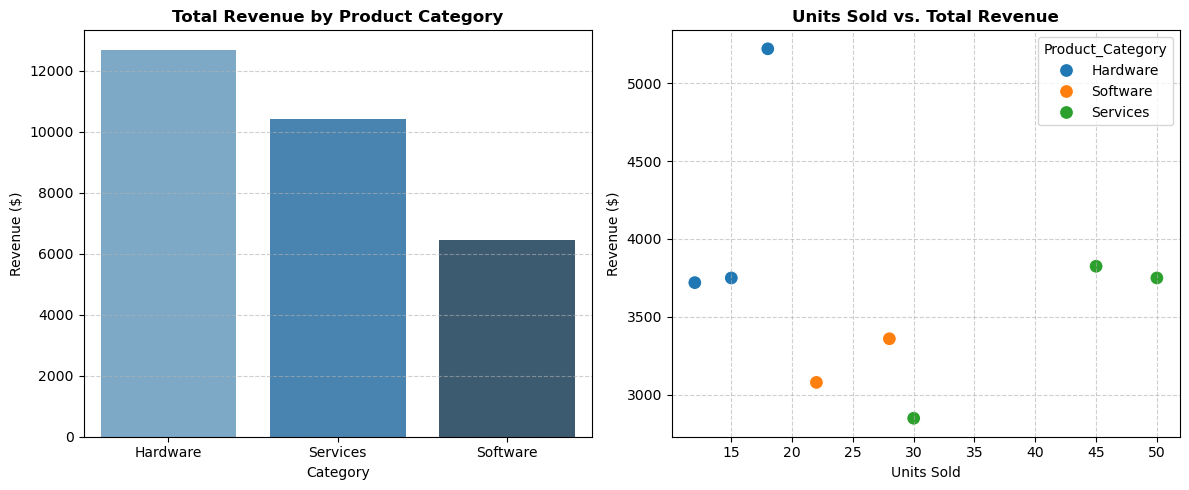

Plots generated and saved as 'lab_visualizations.png'.


In [13]:
# ------------------------------------------------------------------------------
# 4. EXPLORATORY VISUALIZATIONS
# ------------------------------------------------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
# Plot 1: Total Revenue by Product Category (Updated for Seaborn best practices)
category_revenue = df_lab.groupby("Product_Category")["Total_Revenue"].sum().reset_index()
sns.barplot(data=category_revenue, x="Product_Category", y="Total_Revenue", hue="Product_Category", legend=False, ax=axes[0], palette="Blues_d")
axes[0].set_title("Total Revenue by Product Category", fontsize=12, fontweight="bold")
axes[0].set_xlabel("Category")
axes[0].set_ylabel("Revenue ($)")
axes[0].grid(axis="y", linestyle="--", alpha=0.6)
# Plot 2: Units Sold vs Total Revenue
sns.scatterplot(data=df_lab, x="Units_Sold", y="Total_Revenue", hue="Product_Category", s=100, ax=axes[1])
axes[1].set_title("Units Sold vs. Total Revenue", fontsize=12, fontweight="bold")
axes[1].set_xlabel("Units Sold")
axes[1].set_ylabel("Revenue ($)")
axes[1].grid(True, linestyle="--", alpha=0.6)
plt.tight_layout()
plt.savefig("lab_visualizations.png", dpi=300)
plt.show()
print("Plots generated and saved as 'lab_visualizations.png'.")